# TEXT CLASSIFICATION USING NAIVE BAYES AND SENTIMENT ANALYSIS ON BLOG POSTS

### Overview
#### In this assignment, you will work on the "blogs_categories.csv" dataset, which contains blog posts categorized into various themes. Your task will be to build a text classification model using the Naive Bayes algorithm to categorize the blog posts accurately. Furthermore, you will perform sentiment analysis to understand the general sentiment (positive, negative, neutral) expressed in these posts. This assignment will enhance your understanding of text classification, sentiment analysis, and the practical application of the Naive Bayes algorithm in Natural Language Processing (NLP).

### Dataset
#### The provided dataset, "blogs_categories.csv", consists of blog posts along with their associated categories. Each row represents a blog post with the following columns:
### •	Text: 
#### The content of the blog post. Column name: Data

### •	Category: 
#### The category to which the blog post belongs. Column name: Labels

## Tasks
### 1. Data Exploration and Preprocessing
#### •	Load the "blogs_categories.csv" dataset and perform an exploratory data analysis to understand its structure and content.
#### •	Preprocess the data by cleaning the text (removing punctuation, converting to lowercase, etc.), tokenizing, and removing stopwords.
#### •	Perform feature extraction to convert text data into a format that can be used by the Naive Bayes model, using techniques such as TF-IDF.

In [1]:
## Lets import required libraries..

## Data manipulation..
import pandas as pd
import numpy as np

## Data visualization..
import matplotlib.pyplot as plt
import seaborn as sns

## Ignore warnings.. 
import warnings
warnings.filterwarnings("ignore")

## Display settings..
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
## Now lets load and display the dataset..
df = pd.read_csv("blogs.csv")
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [3]:
## Basic informations..

## Shape of the dataset..
print("Shape of the Dataset:", df.shape)

## Columns in dataset..
print("\nColumns in Dataset:")
print(df.columns)

## Information..datatypes and non null values.. 
print("\nDataset Information:")
df.info()

Shape of the Dataset: (2000, 2)

Columns in Dataset:
Index(['Data', 'Labels'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [4]:
## The dataset contains 2,000 blog posts and 2 columns, namely Data (blog text) and Labels (blog category)..
## Both columns are of object datatype and contain 2,000 non-null observations, indicating that the dataset is complete and ready for analysis..

In [5]:
## Statistical summary..
print("Statistical Summary:")
display(df.describe(include = "all").T)

Statistical Summary:


,count,unique,top,freq
Data,2000,2000,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,1
Labels,2000,20,alt.atheism,100


In [6]:
## Checking the number of missing values..
print("Missing Values:")
print(df.isnull().sum().sum())

## Lets check Duplicate rows..
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
0

Duplicate Rows:
0


In [7]:
## The dataset contains no missing values and no duplicate records..
## Therefore, no additional preprocessing is required for handling missing or duplicate data..

In [8]:
## lets have a look at the target distribution..
print(df["Labels"].value_counts())
print("\nUnique Elements: ", df["Labels"].nunique())

## Percentage distribution of each class/alphabets..
print("\nValue Count Percentage:")
print(round(df["Labels"].value_counts(normalize = True)*100, 2))

Labels
alt.atheism                 100
comp.graphics               100
talk.politics.misc          100
talk.politics.mideast       100
talk.politics.guns          100
soc.religion.christian      100
sci.space                   100
sci.med                     100
sci.electronics             100
sci.crypt                   100
rec.sport.hockey            100
rec.sport.baseball          100
rec.motorcycles             100
rec.autos                   100
misc.forsale                100
comp.windows.x              100
comp.sys.mac.hardware       100
comp.sys.ibm.pc.hardware    100
comp.os.ms-windows.misc     100
talk.religion.misc          100
Name: count, dtype: int64

Unique Elements:  20

Value Count Percentage:
Labels
alt.atheism                 5.0
comp.graphics               5.0
talk.politics.misc          5.0
talk.politics.mideast       5.0
talk.politics.guns          5.0
soc.religion.christian      5.0
sci.space                   5.0
sci.med                     5.0
sci.electronics  

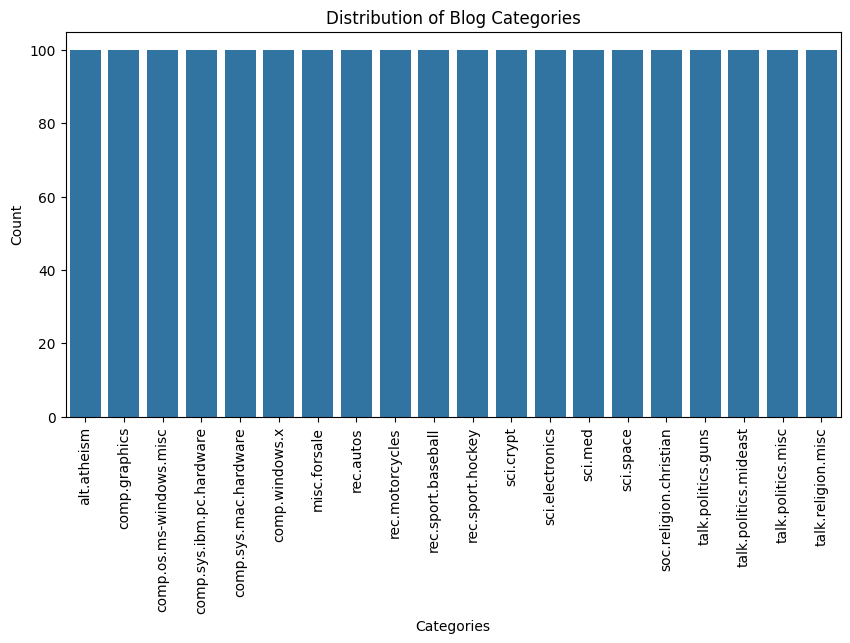

In [9]:
## Lets build a class distribution plot for target variable.. countplot..
plt.figure(figsize = (10, 5))
sns.countplot(x = df["Labels"])
plt.title("Distribution of Blog Categories")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.xticks(rotation = 90)
plt.show()

In [10]:
## The target variable consists of 20 unique blog categories, with 100 observations in each category (5%)..
## Since every category has an equal number of samples, the dataset is perfectly balanced, reducing the risk of classification bias toward any particular class..

In [11]:
## Lets analyse the text length..
df["Text_Length"] = df["Data"].apply(len)

df["Text_Length"].describe()

count     2000.000000
mean      2324.978000
std       3590.560226
min        425.000000
25%       1147.000000
50%       1605.500000
75%       2374.500000
max      62290.000000
Name: Text_Length, dtype: float64

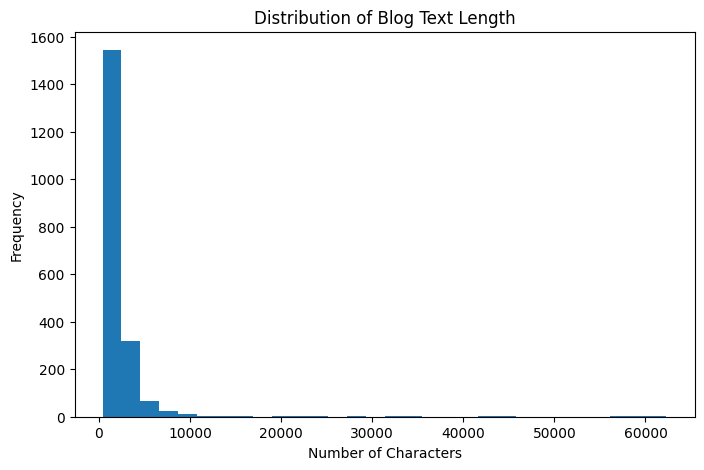

In [12]:
## Histogram for Text Length 
plt.figure(figsize = (8, 5))
plt.hist(df["Text_Length"], bins = 30)
plt.title("Distribution of Blog Text Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

In [13]:
## The average blog length is approximately 2,325 characters, with a median of 1,605 characters..
## The minimum text length is 425 characters, while the maximum reaches 62,290 characters, indicating the presence of a few extremely long blog posts..
## The histogram shows that most blogs are relatively short, with a right-skewed distribution caused by these longer documents..

In [14]:
## Now we will do text preprocessing part..
## Lets import required libraries for that part..
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [15]:
## nltk.download("punkt")
## nltk.download("stopwords")

## Download these if using for the first time..

In [16]:
## Before building the Naive Bayes classifier the text data must be preprocessed because raw text contains unnecessary elements such as punctuation, stopwords, and inconsistent capitalization..
## Cleaning the text helps reduce noise and improves the quality of features extracted for classification..

In [17]:
## Now lets create and define text cleaning function..
def clean_text(text):
    text = text.lower() ## Conversion to lowercase..
    text = text.translate(str.maketrans('', '', string.punctuation)) ## Remove puntuations
    text = re.sub(r'\d+', '', text) ## Remove numbers
    text = re.sub(r'\s+', ' ', text).strip() ## Remove extra spaces
    words = word_tokenize(text) ## Tokenization..

    ## Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [i for i in words if i not in stop_words]

    ## Join words back into text
    return " ".join(words)

In [18]:
## A custom text cleaning function was created to preprocess each blog post..
## The function performs the following operations:
## Converts all text to lowercase to maintain consistency.
## Removes punctuation marks to eliminate unnecessary symbols.
## Removes numerical values as they are generally not useful for text classification in this problem.
## Removes extra spaces to standardize the text format.
## Tokenizes the text by splitting it into individual words.
## Removes common English stopwords (such as the, is, and) that contribute little to the classification task.
## Finally the cleaned words are joined back together to create a processed text representation suitable for feature extraction.

In [19]:
## I got an error in the below code saying 'Resource punkt_tab not found, Please use the NLTK Downloader to obtain the resource:'..
## Lets download it before running next code..
## nltk.download('punkt_tab')

In [20]:
## Now lets apply cleaning..
df["Clean_Data"] = df["Data"].apply(clean_text)

In [21]:
## The cleaning function was applied to every blog post..
## The processed text was stored in a new column named Clean_Data..
## The original Data column was also retained so that the raw text remains available for reference and comparison..

In [22]:
## Lets compare original and cleaned text..
df[["Data", "Clean_Data"]].head()

,Data,Clean_Data
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupesrvcscmuedumagnesiumclubcccmued...
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,newsgroups altatheism path cantaloupesrvcscmue...
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,path cantaloupesrvcscmuedudasnewsharvardedunoc...
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupesrvcscmuedumagnesiumclubcccmued...
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,xref cantaloupesrvcscmuedu altatheism talkreli...


In [23]:
## Now lets come to TF-IDF Feature extraction..
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df["Clean_Data"])
Y = df["Labels"]

In [24]:
## Lets check Feature Matrix
print("TF-IDF Matrix Shape:", X.shape)

TF-IDF Matrix Shape: (2000, 46002)


In [25]:
## Machine learning algorithms cannot work directly with text data..
## TF-IDF (Term Frequency–Inverse Document Frequency) was used to convert the cleaned text into numerical feature vectors..
## TF-IDF assigns higher importance to words that are frequent within a document but less common across all documents making them more useful for classification..
## The resulting TF-IDF matrix has a shape of (2000, 46002) indicating 2000 blog posts represented by 46002 textual features..

### 2. Naive Bayes Model for Text Classification
#### •	Split the data into training and test sets.
#### •	Implement a Naive Bayes classifier to categorize the blog posts into their respective categories. You can use libraries like scikit-learn for this purpose.
#### •	Train the model on the training set and make predictions on the test set.

In [26]:
## Now lets split the dataset using train test split..
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42, stratify = Y)

## The dataset was divided into 80% training data and 20% testing data..
## The stratify=y parameter was used to preserve the original class distribution in both sets ensuring that each blog category is proportionally represented during training and evaluation..

In [27]:
## Now build Naive Bayes Model..
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

In [28]:
## I selected Multinomial Naive Bayes classifier because it is specifically designed for text classification problems and performs effectively on frequency-based features such as TF-IDF vectors..

In [29]:
## Now lets train the model..
nb_model.fit(X_train, Y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [30]:
## The Naive Bayes classifier was trained using the TF-IDF features from the training dataset..
## Enabling it to learn patterns and relationships between words and their corresponding blog categories..

In [31]:
## Lets predict..
Y_pred = nb_model.predict(X_test)

### 3. Sentiment Analysis
#### •	Choose a suitable library or method for performing sentiment analysis on the blog post texts.
#### •	Analyze the sentiments expressed in the blog posts and categorize them as positive, negative, or neutral. Consider only the Data column and get the sentiment for each blog.
#### •	Examine the distribution of sentiments across different categories and summarize your findings.

In [32]:
## if you are using it for the first time then you need to install textblob first..
## !pip install textblob

In [33]:
## Lets import required library..
from textblob import TextBlob

In [34]:
## Now lets create a sentiment function..
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

In [35]:
## Lets  apply sentiment analysis now..
df["Sentiment"] = df["Data"].apply(get_sentiment)

In [36]:
## Sentiment analysis was performed using the TextBlob library by considering only the Data column as required in the assignment..
## Each blog post was assigned a sentiment label based on its polarity score: Positive (polarity > 0), Negative (polarity < 0), and Neutral (polarity = 0).. 

In [37]:
## Lets have a look at first few results..
df[["Data", "Sentiment"]].head()

,Data,Sentiment
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Positive
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,Negative
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,Positive
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,Positive
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,Positive


In [38]:
## Lets check the distribution and percentage..
print("Value Counts of: ", df["Sentiment"].value_counts())
print("\nPercentage of:", (df["Sentiment"].value_counts(normalize = True) * 100).round(2))

Value Counts of:  Sentiment
Positive    1543
Negative     457
Name: count, dtype: int64

Percentage of: Sentiment
Positive    77.15
Negative    22.85
Name: proportion, dtype: float64


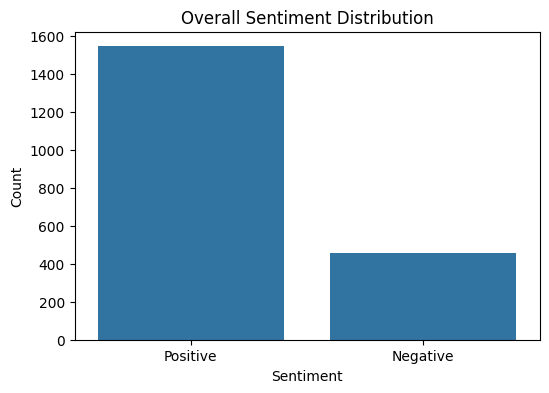

In [39]:
## Lets plot sentiment distribution..
plt.figure(figsize = (6, 4))
sns.countplot(x = df["Sentiment"])
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [40]:
## The sentiment analysis results show that 1543 blogs (77.15%) are classified as Positive, while 457 blogs (22.85%) are classified as Negative..
## No blogs were classified as Neutral indicating that all posts expressed either a positive or a negative sentiment according to the TextBlob polarity scores..

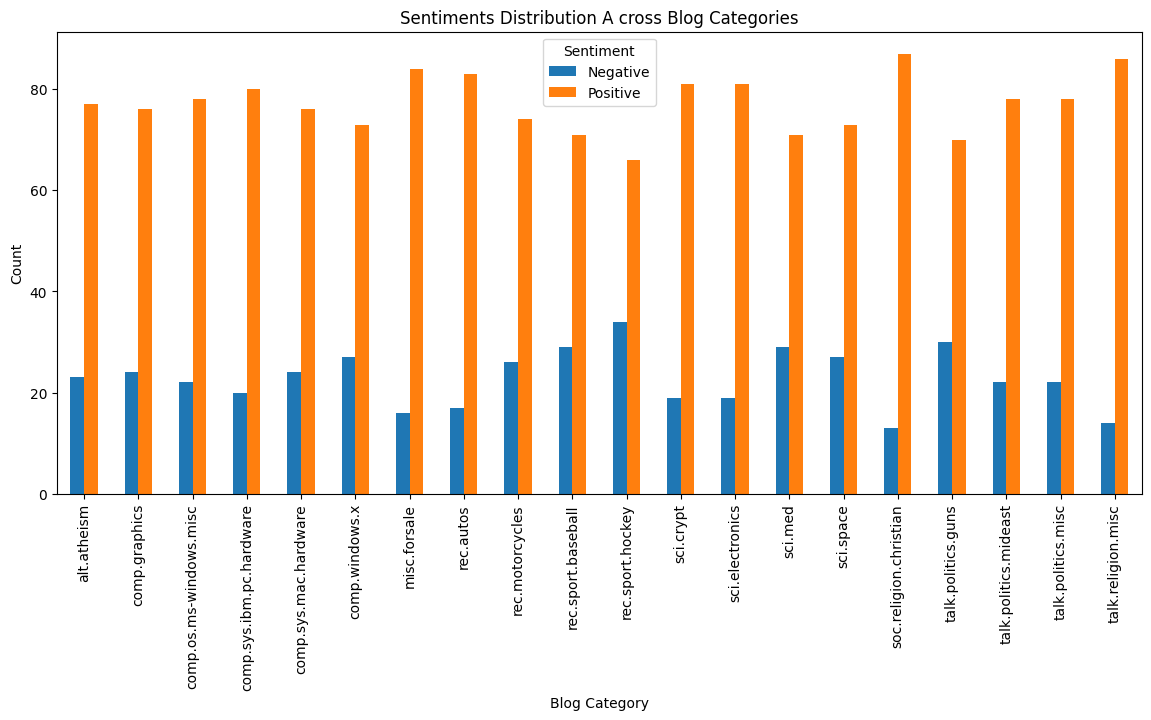

In [41]:
## Now lets Examine the distribution of sentiments across different categories..
sentiment_category = pd.crosstab(df["Labels"], df["Sentiment"])

## Visualization across categories..
sentiment_category.plot(kind = "bar", figsize = (14, 6))
plt.title("Sentiments Distribution A cross Blog Categories")
plt.xlabel("Blog Category")
plt.ylabel("Count")
plt.xticks(rotation = 90)
plt.legend(title = "Sentiment")
plt.show()

In [42]:
## The sentiment distribution across different blog categories indicates that Positive sentiments dominate in every category..
## While Negative sentiments are comparatively fewer..
## Although the number of negative posts varies slightly across categories the overall trend suggests that the majority of blog posts in this dataset express positive sentiment..
## TextBlob assigns sentiment based on the polarity of the text..
## In this dataset every blog received a polarity score either greater than or less than zero resulting in Positive or Negative classifications only..
## Therefore no blog was labeled as Neutral..
## By analyzing only the Data column the sentiment analysis reveals that the dataset is predominantly positive in nature.. ## With approximately 3/4 of the blog posts expressing positive sentiment across the various categories..

### 4. Evaluation
#### •	Evaluate the performance of your Naive Bayes classifier using metrics such as accuracy, precision, recall, and F1-score.
#### •	Discuss the performance of the model and any challenges encountered during the classification process.
#### •	Reflect on the sentiment analysis results and their implications regarding the content of the blog posts.

In [43]:
## Lets calculate accuracy now..
from sklearn.metrics import accuracy_score

print("Accuracy: ", accuracy_score(Y_test, Y_pred))

Accuracy:  0.845


In [44]:
## The Naive Bayes classifier achieved an accuracy of 84.5% indicating that it correctly classified approximately 85 out of every 100 blog posts into their respective categories..
## This demonstrates that the TF-IDF features combined with the Naive Bayes algorithm are effective for text classification..

In [45]:
## Classification report (precision, recall, f1 score)..
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred))

                          precision    recall  f1-score   support

             alt.atheism       0.76      0.65      0.70        20
           comp.graphics       0.89      0.80      0.84        20
 comp.os.ms-windows.misc       0.85      0.85      0.85        20
comp.sys.ibm.pc.hardware       0.60      0.75      0.67        20
   comp.sys.mac.hardware       0.88      0.75      0.81        20
          comp.windows.x       0.94      0.85      0.89        20
            misc.forsale       0.85      0.85      0.85        20
               rec.autos       0.90      0.90      0.90        20
         rec.motorcycles       0.95      0.90      0.92        20
      rec.sport.baseball       0.95      1.00      0.98        20
        rec.sport.hockey       0.95      1.00      0.98        20
               sci.crypt       0.91      1.00      0.95        20
         sci.electronics       0.84      0.80      0.82        20
                 sci.med       0.94      0.80      0.86        20
         

In [46]:
## The classification report shows the precision, recall, and F1-score for each blog category..
## Most categories have values above 0.80 indicating good classification performance..
## Some categories such as rec.sport.baseball, rec.sport.hockey, and sci.crypt achieved very high scores..
## While a few categories like talk.religion.misc and alt.atheism showed comparatively lower performance due to similarities with other topics..
## Overall the macro and weighted averages of approximately 0.85 indicate a well-performing model..

In [47]:
## Confusion matrix.. 
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, Y_pred)

print(cm)

[[13  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0  0  0  5]
 [ 1 16  0  1  0  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0 17  2  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  2 15  1  0  0  0  0  0  0  0  2  0  0  0  0  0  0  0]
 [ 0  0  1  3 15  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  1  0  1  0 17  0  0  0  0  0  1  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  1  0 17  0  0  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 18  1  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  1  0  0  0  1 18  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  0  2  1  0  0  0  0 16  0  0  0  0  0  0  0]
 [ 1  1  0  0  0  0  1  0  0  0  0  0  0 16  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 19  0  1  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 20  0  0

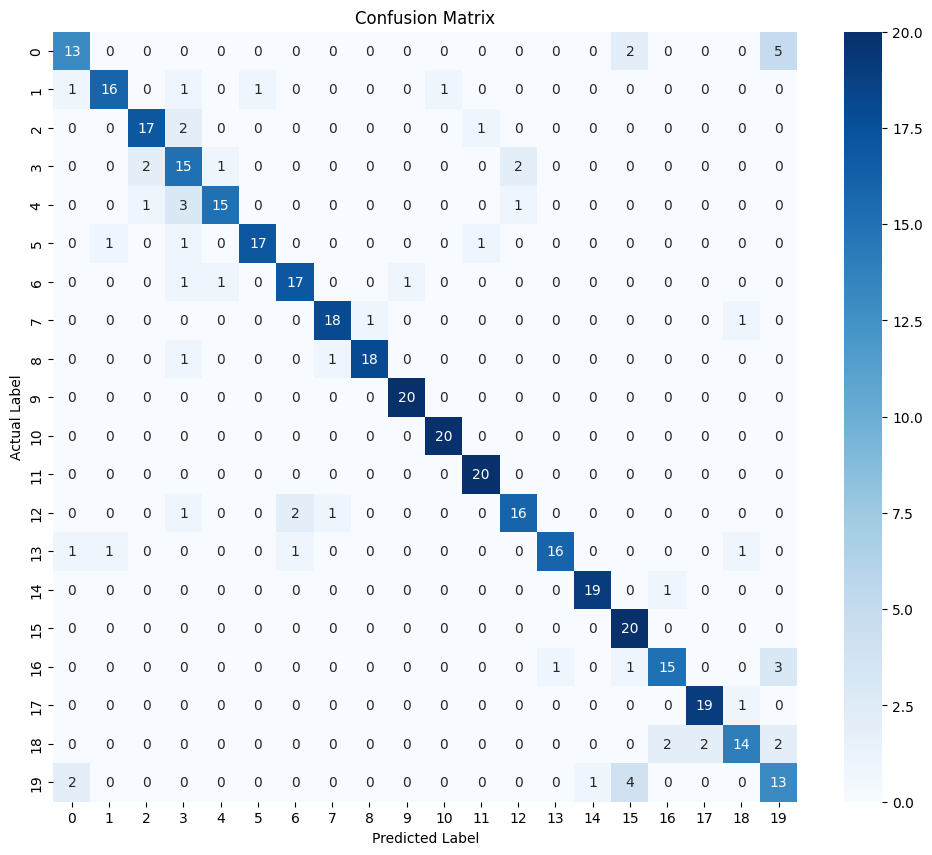

In [48]:
## Visualize Confusion Matrix..
plt.figure(figsize = (12, 10))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [49]:
## The confusion matrix summarizes the model’s correct and incorrect predictions..
## Most values are concentrated along the main diagonal indicating that the majority of blog posts were classified correctly..
## The few off-diagonal values represent misclassifications between categories with similar textual content which is expected in multi-class text classification problems..

In [50]:
## Lets compare actual vs predicted.. 
comparison = pd.DataFrame({"Actual": Y_test.values, "Predicted": Y_pred})
comparison.head(10)

,Actual,Predicted
0,sci.crypt,sci.crypt
1,sci.med,sci.med
2,talk.politics.mideast,talk.politics.mideast
3,soc.religion.christian,soc.religion.christian
4,talk.politics.guns,talk.politics.guns
5,sci.med,sci.med
6,comp.windows.x,comp.windows.x
7,rec.motorcycles,rec.motorcycles
8,talk.politics.mideast,talk.politics.mideast
9,comp.graphics,comp.graphics


In [51]:
## The comparison table displays the actual category alongside the category predicted by the model for selected test samples..
## It provides a simple way to verify whether individual predictions are correct and helps identify specific instances where the classifier makes errors..

In [52]:
## Final Conclusion: 
## Performance of the model and any challenges encountered during the classification process.. 
## Reflection on the sentiment analysis results and their implications regarding the content of the blog posts..

## The objective of this assignment was to classify blog posts into their respective categories using the Naive Bayes algorithm and to perform sentiment analysis on the blog text..
## The dataset was first explored and preprocessed by cleaning the text, converting it to lowercase, removing punctuation and stopwords, and transforming the cleaned text into numerical features using the TF-IDF technique..
## These preprocessing steps helped convert unstructured textual data into a suitable format for machine learning..

## The Naive Bayes classifier was trained on the processed data and evaluated on the test set..
## The model achieved an accuracy of 84.5% demonstrating that it is effective in classifying blog posts across the 20 different categories..
## The classification report showed good precision, recall, and F1-score for most classes, while a few categories achieved comparatively lower scores..
## These lower scores are expected because certain blog categories contain similar vocabulary and contextual information making them more difficult to distinguish..
## The confusion matrix further indicated that most predictions were correct as the majority of values were concentrated along the main diagonal, with only a limited number of misclassifications..

## For sentiment analysis the TextBlob library was used by considering only the Data column as specified in the assignment..
## The analysis revealed that 77.15% of the blog posts were classified as Positive, while 22.85% were classified as Negative..
## No posts were classified as Neutral because all blog texts received polarity scores either above or below zero..
## The sentiment distribution across different blog categories showed that positive sentiment dominated in every category, suggesting that the overall tone of the dataset is generally positive..

## One of the challenges encountered during the classification process is that text data from different categories may share common words and similar writing styles, which can lead to occasional misclassification..
## In addition, sentiment analysis based on lexical methods such as TextBlob may not always capture sarcasm, context or complex emotions perfectly..
## Nevertheless the combination of TF-IDF feature extraction and the Naive Bayes classifier produced a strong classification model..
## While sentiment analysis provided additional insights into the emotional tone of the blog posts..
## Overall the assignment demonstrates the practical application of Natural Language Processing techniques for both text classification and sentiment analysis.